In [6]:
import json
import pickle
import re
import unicodedata
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import sklearn_crfsuite
from sklearn_crfsuite import metrics as crf_metrics
from sklearn.model_selection import train_test_split
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

### Access the data

In [ ]:
data_dir = Path('..\..\datasets\processed_data')

with open(data_dir / 'processed.pkl', 'rb') as f:
    processed = pickle.load(f)

with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    token2id = v['token2id'];   id2token   = v['id2token']
    label2id = v['label2id'];   id2label   = v['id2label']
    char2id = v['char2id'];    id2char    = v['id2char']
    PAD_ID = v['PAD_ID'];     UNK_ID     = v['UNK_ID']
    PAD_LABEL_ID = v['PAD_LABEL_ID']
    Entity_labels = v['Entity_labels']
    MAX_LEN_LSTM = v['MAX_LEN_LSTM']
    MAX_LEN_BERT = v['MAX_LEN_BERT']

### Feature Engineering

In [ ]:
# Lightweight regex POS tagger (no external dependency)
# Covers the most discriminative POS patterns for resume NER.
# In production, replace with spaCy: nlp(text).pos_

_POS_RULES = [
    (re.compile(r'^\d{4}$'),                  'CD_YEAR'),   # graduation year
    (re.compile(r'^\d+$'),                    'CD'),        # other digits
    (re.compile(r'^[A-Z][a-z]+$'),            'NNP'),       # TitleCase → proper noun
    (re.compile(r'^[A-Z]{2,}$'),              'NNP_ABB'),   # ALLCAPS → abbreviation
    (re.compile(r'.+ing$',re.I),              'VBG'),       # gerund
    (re.compile(r'.+ed$',re.I),               'VBD'),       # past tense
    (re.compile(r'.+er$',re.I),               'NN_ER'),     # developer, manager
    (re.compile(r'.+ly$',re.I),               'RB'),        # adverb
    (re.compile(r'.+tion$|.+sion$',re.I),     'NN_TION'),   # graduation, solution
    (re.compile(r'.+ment$',re.I),             'NN_MENT'),   # management
    (re.compile(r'@'),                        'EMAIL'),
    (re.compile(r'[+#]|\d'),                  'TECH'),      # C++, HTML5
]

def regex_pos(token: str) -> str:
    for pattern, tag in _POS_RULES:
        if pattern.search(token):
            return tag
    return 'NN'   # default: common noun


# Dual-token feature 

def align_raw_norm(raw_bio, norm_bio):
    """Pair each normalized token back to its original raw form."""
    aligned = []
    raw_iter = iter(raw_bio)
    for norm_tok, norm_tag in norm_bio:
        for raw_tok, raw_tag in raw_iter:
            if raw_tag == norm_tag:
                aligned.append((raw_tok, norm_tok, norm_tag))
                break
    return aligned


def token_features(raw_tok: str, norm_tok: str,
                   idx: int, raw_seq: list, norm_seq: list) -> dict:
    """
    Build CRF feature dictionary for one token.

    Orthographic flags  -> raw_tok  (casing / punctuation intact)
    Prefix/suffix       -> norm_tok (consistent normalized form)
    POS tag             -> raw_tok  (regex-based)
    Context window      -> both raw neighbours
    """
    prev_raw = raw_seq[idx - 1] if idx > 0 else '<START>'
    next_raw = raw_seq[idx + 1] if idx < len(raw_seq) - 1 else '<END>'

    feat = {
        # Identity 
        'token'            : norm_tok,
        'pos'              : regex_pos(raw_tok),

        # Orthographic (raw) 
        'is_title_case'    : raw_tok.istitle(),
        'is_all_upper'     : raw_tok.isupper(),
        'is_all_lower'     : raw_tok.islower(),
        'is_digit'         : raw_tok.isdigit(),
        'has_digit'        : any(c.isdigit() for c in raw_tok),
        'is_alnum'         : raw_tok.isalnum(),
        'has_hyphen'       : '-' in raw_tok,
        'has_at'           : '@' in raw_tok,
        'has_dot'          : '.' in raw_tok,
        'has_plus'         : '+' in raw_tok,
        'has_slash'        : '/' in raw_tok,

        # Shape 
        'token_length'     : len(raw_tok),
        'is_short'         : len(raw_tok) <= 2,

        # Prefix / suffix (normalized) 
        'prefix2'          : norm_tok[:2],
        'prefix3'          : norm_tok[:3],
        'prefix4'          : norm_tok[:4],
        'suffix2'          : norm_tok[-2:],
        'suffix3'          : norm_tok[-3:],
        'suffix4'          : norm_tok[-4:],

        # Context bigrams (raw)
        'prev_token'       : prev_raw.lower(),
        'prev_is_title'    : prev_raw.istitle(),
        'prev_is_upper'    : prev_raw.isupper(),
        'prev_pos'         : regex_pos(prev_raw),
        'next_token'       : next_raw.lower(),
        'next_is_title'    : next_raw.istitle(),
        'next_is_upper'    : next_raw.isupper(),
        'next_pos'         : regex_pos(next_raw),

        # Position
        'is_sentence_start': idx == 0,
        'is_sentence_end'  : idx == len(raw_seq) - 1,
    }
    return feat


def sequence_features(raw_bio, norm_bio):
    aligned = align_raw_norm(raw_bio, norm_bio)
    raw_toks = [r for r, _, _ in aligned]
    norm_toks = [n for _, n, _ in aligned]
    return [
        token_features(raw_toks[i], norm_toks[i], i, raw_toks, norm_toks)
        for i in range(len(aligned))
    ]

# Demo
demo_feats = sequence_features(
    processed[0]['word_bio_raw'],
    processed[0]['word_bio_norm']
)
show_keys = ['token','pos','is_title_case','is_all_upper','is_digit','has_at','prefix3','suffix3','prev_token','next_token']
demo_tags = [tag for _,tag in processed[0]['word_bio_norm']]

print(f"{'BIO Tag':<28}" + ''.join(f"{k:<18}" for k in show_keys))
print("=" * (28 + 18 * len(show_keys)))
for tag, feat in zip(demo_tags[:10], demo_feats[:10]):
    print(f"{tag:<28}" + ''.join(f"{str(feat[k]):<18}" for k in show_keys))

BIO Tag                     token             pos               is_title_case     is_all_upper      is_digit          has_at            prefix3           suffix3           prev_token        next_token        
B-Name                      abhishek          NNP               True              False             False             False             abh               hek               <start>           jha               
I-Name                      jha               NNP               True              False             False             False             jha               jha               abhishek          application       
B-Designation               application       NNP               True              False             False             False             app               ion               jha               development       
I-Designation               development       NNP               True              False             False             False             dev               ent       

### Building Dataset

In [ ]:
# Build X (feature sequences) and y (label sequences) for all resumes
X_all, y_all = [], []

for p in processed:
    feats = sequence_features(p['word_bio_raw'], p['word_bio_norm'])
    labels = [tag for _, tag in p['word_bio_norm']]
    X_all.append(feats)
    y_all.append(labels)

print(f"Sequences : {len(X_all)}")
print(f"Avg length: {sum(len(s) for s in X_all)/len(X_all):.1f} tokens")
print(f"Features per token: {len(X_all[0][0])}")

Sequences : 220
Avg length: 485.4 tokens
Features per token: 31


In [15]:
# Train / Validation / Test split  (70 / 15 / 15)
from sklearn.model_selection import train_test_split

indices = list(range(len(X_all)))
idx_train, idx_temp = train_test_split(indices, test_size=0.30, random_state=42)
idx_val,   idx_test = train_test_split(idx_temp,  test_size=0.50, random_state=42)

X_train = [X_all[i] for i in idx_train]
y_train = [y_all[i] for i in idx_train]
X_val = [X_all[i] for i in idx_val]
y_val = [y_all[i] for i in idx_val]
X_test = [X_all[i] for i in idx_test]
y_test = [y_all[i] for i in idx_test]

print(f"Train : {len(X_train)} resumes  ({len(X_train)/len(X_all)*100:.0f}%)")
print(f"Val   : {len(X_val)}  resumes  ({len(X_val)/len(X_all)*100:.0f}%)")
print(f"Test  : {len(X_test)}  resumes  ({len(X_test)/len(X_all)*100:.0f}%)")

Train : 154 resumes  (70%)
Val   : 33  resumes  (15%)
Test  : 33  resumes  (15%)


Save split data (Supaya dat ayang diapke buat semua model sama)

In [20]:
# Save split indices — run ONCE, all other models load this
split = {
    'idx_train': idx_train,
    'idx_val'  : idx_val,
    'idx_test' : idx_test,
}

split_dir = Path('../../datasets/split_data')
split_dir.mkdir(exist_ok=True)

with open(split_dir / 'split_indices.json', 'w') as f:
    json.dump(split, f)

print("Split saved -> split_indices.json")
print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

Split saved -> split_indices.json
Train: 154 | Val: 33 | Test: 33


### Hyperparameter Tuning

In [ ]:
from itertools import product

c1_values = [0.01, 0.1, 0.5]
c2_values = [0.01, 0.1, 0.5]
MAX_ITER = 100

grid_results = []

print(f"Grid search: {len(c1_values)}×{len(c2_values)} = {len(c1_values)*len(c2_values)} combos")
print(f"{'c1':<8} {'c2':<8} {'Val F1':>10}")
print("=" * 30)

for c1, c2 in product(c1_values, c2_values):
    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=c1,
        c2=c2,
        max_iterations=MAX_ITER,
        all_possible_transitions=True
    )
    crf.fit(X_train, y_train)
    y_pred_val = crf.predict(X_val)
    f1 = f1_score(y_val, y_pred_val)
    grid_results.append({'c1': c1, 'c2': c2, 'val_f1': f1})
    print(f"{c1:<8} {c2:<8} {f1:>10.4f}")

best = max(grid_results, key=lambda x: x['val_f1'])
print(f"\nBest -> c1={best['c1']}, c2={best['c2']}, val_f1={best['val_f1']:.4f}")

Grid search: 3×3 = 9 combos
c1       c2           Val F1
0.01     0.01         0.5507
0.01     0.1          0.5551
0.01     0.5          0.5603
0.1      0.01         0.5815
0.1      0.1          0.5863
0.1      0.5          0.5546
0.5      0.01         0.5841
0.5      0.1          0.5802
0.5      0.5          0.5860

Best -> c1=0.1, c2=0.1, val_f1=0.5863


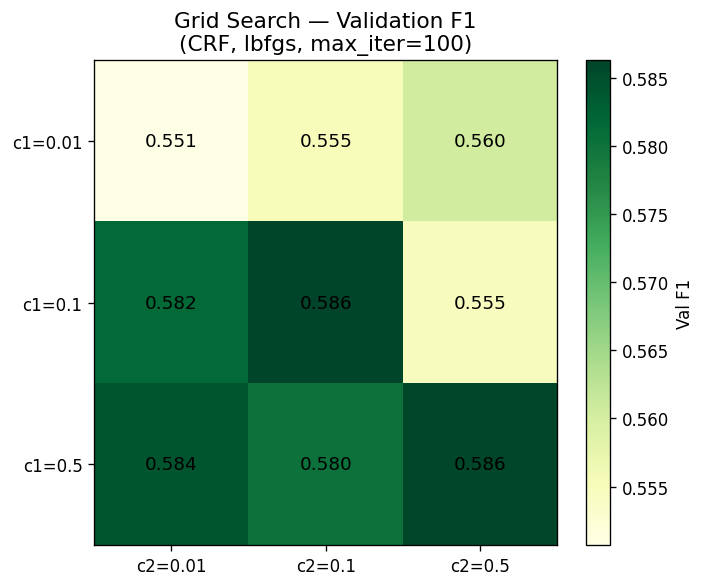

In [22]:
# Visualise grid search heatmap
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index='c1', columns='c2', values='val_f1')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(c2_values)))
ax.set_yticks(range(len(c1_values)))
ax.set_xticklabels([f"c2={v}" for v in c2_values])
ax.set_yticklabels([f"c1={v}" for v in c1_values])
for i in range(len(c1_values)):
    for j in range(len(c2_values)):
        ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha='center', va='center', fontsize=11)
plt.colorbar(im, ax=ax, label='Val F1')
ax.set_title("Grid Search — Validation F1\n(CRF, lbfgs, max_iter=100)")
plt.tight_layout()
plt.show()

### Train Model

In [25]:
# Train with best hyperparameters on train+val
X_trainval = X_train + X_val
y_trainval = y_train + y_val

crf_final = sklearn_crfsuite.CRF(
    algorithm = 'lbfgs',
    c1 = best['c1'],
    c2 = best['c2'],
    max_iterations  = 200,          # more iterations for final model
    all_possible_transitions = True
)
crf_final.fit(X_trainval, y_trainval)

print(f"Final model trained on {len(X_trainval)} resumes")
print(f"c1={best['c1']}, c2={best['c2']}, max_iterations=200")
print(f"Classes: {len(crf_final.classes_)}")

Final model trained on 187 resumes
c1=0.1, c2=0.1, max_iterations=200
Classes: 20
